In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rahulsah06/titanic/train.csv
/kaggle/input/datasets/rahulsah06/titanic/test.csv
/kaggle/input/datasets/rahulsah06/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
train = pd.read_csv('/kaggle/input/datasets/rahulsah06/titanic/train.csv')

train.head()
test = pd.read_csv('/kaggle/input/datasets/rahulsah06/titanic/test.csv')

In [4]:
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())

train['Fare'] = train['Fare'].fillna(train['Fare'].median())
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

train['Embarked'] = train['Embarked'].fillna(
    train['Embarked'].mode()[0]
)

test['Embarked'] = test['Embarked'].fillna(
    test['Embarked'].mode()[0]
)

In [5]:
train['Age'] = train['Age'].fillna(
    train['Age'].median()
)

test['Age'] = test['Age'].fillna(
    test['Age'].median()
)

train['Fare'] = train['Fare'].fillna(
    train['Fare'].median()
)

test['Fare'] = test['Fare'].fillna(
    test['Fare'].median()
)

train['Embarked'] = train['Embarked'].fillna(
    train['Embarked'].mode()[0]
)

test['Embarked'] = test['Embarked'].fillna(
    test['Embarked'].mode()[0]
)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train['Embarked'] = le.fit_transform(train['Embarked'])
test['Embarked'] = le.transform(test['Embarked'])

In [7]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_dark"

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(

    x=train['Age'],
    y=train['Fare'],
    z=train['PassengerId'],

    mode='markers',

    marker=dict(
        size=5,
        color=train['Survived'],
        colorscale='Turbo',
        opacity=0.8
    ),

    text=train['Name']
))

fig.update_layout(

    title=' Titanic Survival Galaxy',

    width=1300,
    height=850,

    paper_bgcolor='black',
    plot_bgcolor='black',

    font=dict(color='white')
    
)

fig.show()



In [9]:
import plotly.express as px

small_data = train.sample(300)

fig = px.scatter_3d(
    small_data,

    x='Age',
    y='Fare',
    z='PassengerId',

    color='Survived',

    opacity=0.7
)

fig.update_layout(
    width=800,
    height=500
)

fig.show()

## PCA TSNE

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = train[
    ['Age', 'Fare', 'Pclass', 'Sex']
]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=3)

pca_result = pca.fit_transform(scaled)

train['PCA1'] = pca_result[:,0]
train['PCA2'] = pca_result[:,1]
train['PCA3'] = pca_result[:,2]

## PCA 3D PLOTS 

In [11]:
fig = px.scatter_3d(

    train.sample(300),

    x='PCA1',
    y='PCA2',
    z='PCA3',

    color='Survived'
)

fig.update_layout(
    width=800,
    height=500
)

fig.show()

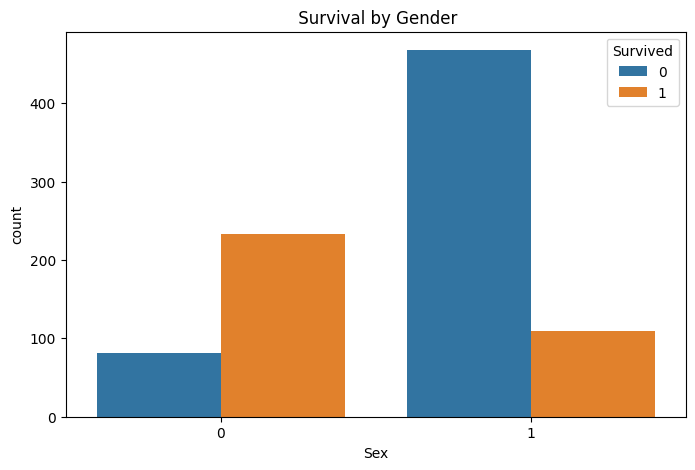

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=train
)

plt.title(" Survival by Gender")

plt.show()

## FARE DISTRIBUTIONS

In [13]:
fig = px.histogram(

    train,

    x='Fare',

    color='Survived',

    nbins=50,

    title=' Fare Distribution'
)

fig.update_layout(
    width=900,
    height=500
)

fig.show()

## CORRELATION HEATMAP

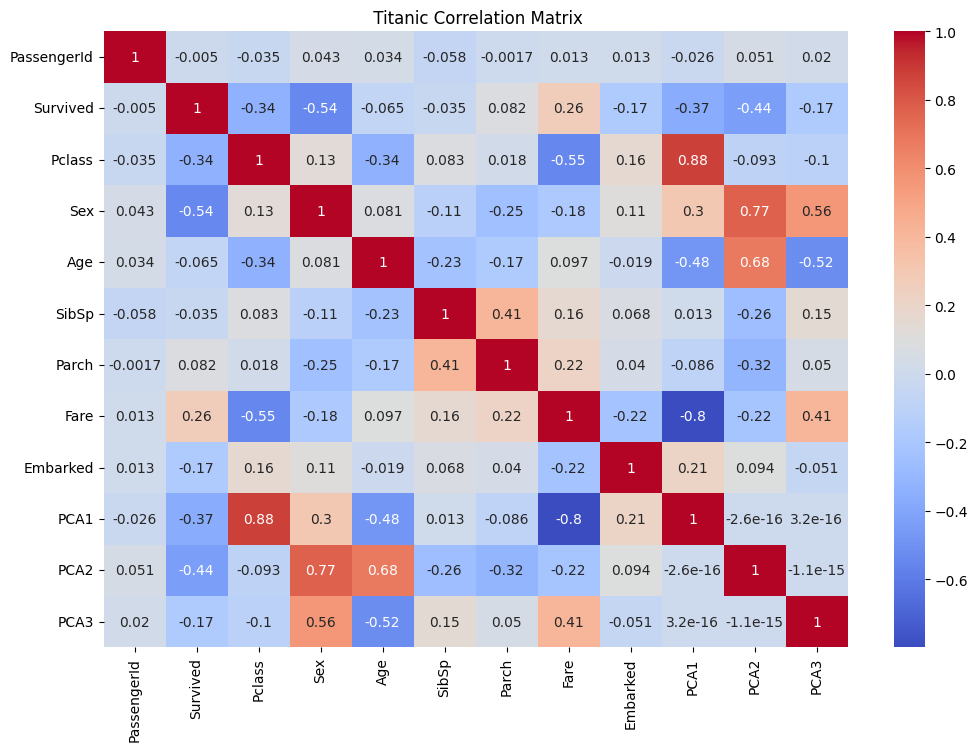

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(

    train.corr(numeric_only=True),

    annot=True,

    cmap='coolwarm'
)

plt.title(" Titanic Correlation Matrix")

plt.show()

## PASSENGER CLASS ANALYSISM

In [15]:
fig = px.box(

    train,

    x='Pclass',

    y='Age',

    color='Survived',

    title=' Passenger Class vs Age'
)

fig.show()

In [16]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(

    x=train['Age'],
    y=train['Fare'],
    z=train['PassengerId'],

    mode='markers',

    marker=dict(

        size=5,

        color=train['Survived'],

        colorscale='Plasma',

        opacity=0.8
    ),

    text=train['Name'],

    hovertemplate=
    'Passenger: %{text}<br>Age: %{x}<br>Fare: %{y}'
))

fig.update_layout(

    title=' Titanic Survival Galaxy',

    paper_bgcolor='black',

    plot_bgcolor='black',

    font=dict(color='white'),

    width=1000,

    height=700,

    scene=dict(

        bgcolor='black',

        xaxis=dict(
            backgroundcolor='black',
            color='white'
        ),

        yaxis=dict(
            backgroundcolor='black',
            color='white'
        ),

        zaxis=dict(
            backgroundcolor='black',
            color='white'
        )
    )
)

fig.show()

## FEATURE IMPORTANCE MODEL

In [17]:
from sklearn.ensemble import RandomForestClassifier

features = [

    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X_train = train[features]

y_train = train['Survived']

X_test = test[features]

model = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

## FEATURE IMPORTANCE PLOT

In [18]:
importance = pd.DataFrame({

    'Feature': features,

    'Importance': model.feature_importances_
})

importance = importance.sort_values(

    by='Importance',

    ascending=False
)

fig = px.bar(

    importance,

    x='Importance',

    y='Feature',

    orientation='h',

    title=' Feature Importance'
)

fig.show()

## FAMILY SIZE 

In [19]:
train['FamilySize'] = (
    train['SibSp'] + train['Parch'] + 1
)

test['FamilySize'] = (
    test['SibSp'] + test['Parch'] + 1
)

## IS ALONE

In [20]:
train['IsAlone'] = 0

train.loc[
    train['FamilySize'] == 1,
    'IsAlone'
] = 1

test['IsAlone'] = 0

test.loc[
    test['FamilySize'] == 1,
    'IsAlone'
] = 1

## PREDICTIONS

In [21]:
predictions = model.predict(X_test)

## CREATE SUBMISSION FILES 

In [22]:
submission = pd.DataFrame({

    'PassengerId': test['PassengerId'],

    'Survived': predictions
})

submission.to_csv(

    'submission.csv',

    index=False
)

print(" Submission file created!")

 Submission file created!
